# Resnet-18 Training

## Vollständiger Test-Code (zum Debuggen): nach manuelles Download: test ob daten vorliegen

Dataset:

  ├── speichert Metadaten
  
  ├── speichert Pfade
  
  └── lädt Daten erst bei __getitem__(idx)

  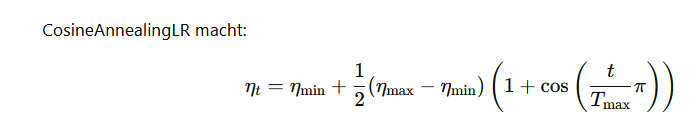

  

## Load file: trainset = torchvision.datasets.CIFAR10(root=root, train=True, download=True, transform=transform)

In [6]:
import os
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([transforms.ToTensor()])
root = './data'

# Check Ordner
if not os.path.exists(root):
    print("Erstelle ./data/")
    os.makedirs(root)

cifar_dir=os.path.join(root, 'cifar-10-batches-py')
print("Bilder Ordner:", cifar_dir)
print("CIFAR-10 Ordner vorhanden:", os.path.exists(os.path.join(root, 'cifar-10-batches-py')))
print("Train batches:", os.listdir(cifar_dir) if os.path.exists(cifar_dir) else "NICHT GEFUNDEN")

# Test-Laden
try:
    print("✅ starten geladen:")
    trainset = torchvision.datasets.CIFAR10(root=root, train=True, download=True, transform=transform)
    print("✅ Train geladen:", len(trainset))
    testset = torchvision.datasets.CIFAR10(root=root, train=False, download=True, transform=transform)
    print("✅ Test geladen:", len(testset))
except Exception as e:
    print("❌ Fehler:", e)


Bilder Ordner: ./data\cifar-10-batches-py
CIFAR-10 Ordner vorhanden: True
Train batches: ['batches.meta', 'data_batch_1', 'data_batch_2', 'data_batch_3', 'data_batch_4', 'data_batch_5', 'readme.html', 'test_batch']
✅ starten geladen:
✅ Train geladen: 50000
✅ Test geladen: 10000


## ResNet-18 Trainingscode with  CIFAR-10 (32x32 format Bilder), ImageNet too big to train hier

## Version 1:

Training auf: cuda:0
GPU: NVIDIA RTX 3500 Ada Generation Laptop GPU
Pos1:
Pos2:
Dataset geladen! Train samples: 50000 Test samples: 10000
Pos3:
Train batches: 196, Test batches: 40

Starte Training...

Batch 0/196 Loss: 2.419 Acc: 8.98%
Batch 100/196 Loss: 2.060 Acc: 15.68%
Epoch 1/20:
  Train Loss: 2.299, Train Acc: 21.85%
  Test Loss: 1.733, Test Acc: 35.31%
  LR: 0.100000

Batch 0/196 Loss: 1.755 Acc: 33.98%
Batch 100/196 Loss: 1.704 Acc: 36.00%
Epoch 2/20:
  Train Loss: 1.656, Train Acc: 38.49%
  Test Loss: 1.490, Test Acc: 43.77%
  LR: 0.100000

Batch 0/196 Loss: 1.601 Acc: 39.45%
Batch 100/196 Loss: 1.453 Acc: 45.96%
Epoch 3/20:
  Train Loss: 1.412, Train Acc: 47.99%
  Test Loss: 1.426, Test Acc: 47.39%
  LR: 0.100000

Batch 0/196 Loss: 1.297 Acc: 53.52%
Batch 100/196 Loss: 1.268 Acc: 54.57%
Epoch 4/20:
  Train Loss: 1.192, Train Acc: 56.87%
  Test Loss: 1.202, Test Acc: 56.96%
  LR: 0.100000

Batch 0/196 Loss: 1.087 Acc: 62.89%
Batch 100/196 Loss: 0.960 Acc: 63.30%
Epoch 5/20:
 

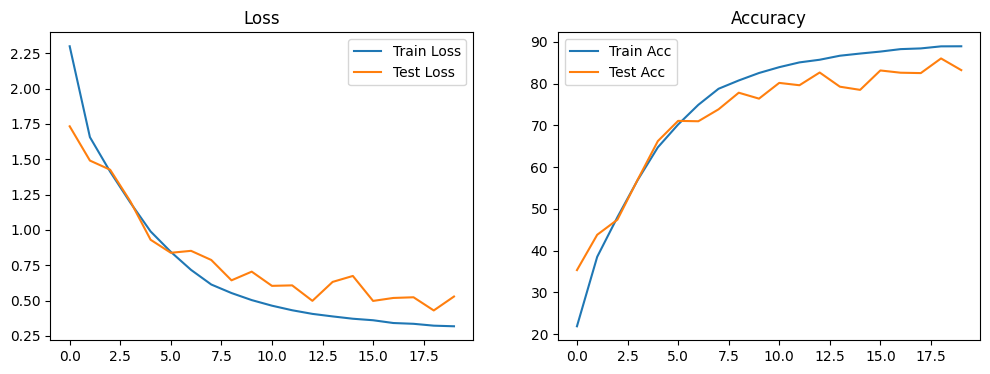


Beispiel-Vorhersagen (erwartet vs. vorhergesagt):
cat -> cat
ship -> ship
ship -> ship
plane -> ship


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
import matplotlib.pyplot as plt
import numpy as np

# Gerät erkennen (deine RTX 3500 Ada)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Training auf: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Data Augmentation für CIFAR-10 (32x32 Bilder)
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
print("Pos1:")
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
print("Pos2:")
# CIFAR-10 laden (automatisch download)
#trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
# ... (gleicher Import-Block wie vorher)

# Dataset laden OHNE Download (aus ./data/)
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform_test)

print("Dataset geladen! Train samples:", len(trainset), "Test samples:", len(testset))

# Rest des Codes unverändert (DataLoader, Model, Training...)


print("Pos3:")
trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True, num_workers=8)

#testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=8)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(f"Train batches: {len(trainloader)}, Test batches: {len(testloader)}")

# ResNet-18 anpassen für CIFAR-10 (Input: 3x32x32, Output: 10 Klassen)
#model = resnet18(pretrained=False)  # Kein Pretraining für CIFAR
model = resnet18(weights=None)  # Modern: weights=None
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)  # Anpassung für 32x32
model.maxpool = nn.Identity()  # Kein MaxPool nach conv1
model.fc = nn.Linear(model.fc.in_features, 10)  # 10 Klassen
model = model.to(device)

# Loss, Optimizer, Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[100, 150], gamma=0.1)

# Training Funktion
def train_epoch(model, trainloader, criterion, optimizer, device):
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0
    for batch_idx, (inputs, targets) in enumerate(trainloader):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        
        if batch_idx % 100 == 0:
            print(f'Batch {batch_idx}/{len(trainloader)} Loss: {loss.item():.3f} Acc: {100.*correct/total:.2f}%')
    return train_loss / len(trainloader), 100. * correct / total

# Test Funktion
def test_epoch(model, testloader, criterion, device):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in testloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return test_loss / len(testloader), 100. * correct / total

# Training Loop (z.B. 20 Epochen für ~93% Test-Acc)
num_epochs = 20   #20 bis 40
train_losses, train_accs = [], []
test_losses, test_accs = [], []

print("\nStarte Training...\n")
for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, trainloader, criterion, optimizer, device)
    test_loss, test_acc = test_epoch(model, testloader, criterion, device)
    
    scheduler.step()
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    print(f'Epoch {epoch+1}/{num_epochs}:')
    print(f'  Train Loss: {train_loss:.3f}, Train Acc: {train_acc:.2f}%')
    print(f'  Test Loss: {test_loss:.3f}, Test Acc: {test_acc:.2f}%')
    print(f'  LR: {scheduler.get_last_lr()[0]:.6f}\n')

print("Training fertig! Modell speichern:")
torch.save(model.state_dict(), 'resnet18_cifar10.pth')
print("Gespeichert als 'resnet18_cifar10.pth'")

# Plots
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(test_accs, label='Test Acc')
plt.legend()
plt.title('Accuracy')
plt.show()

# Beispiel-Vorhersagen auf Test-Set (Ausgabe simulieren)
model.eval()
dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images[:4].to(device), labels[:4].to(device)

outputs = model(images)
_, predicted = torch.max(outputs, 1)
print("\nBeispiel-Vorhersagen (erwartet vs. vorhergesagt):")
for i in range(4):
    print(f'{classes[labels[i]]} -> {classes[predicted[i]]}')


# Mit der Ada-Architektur deiner RTX 3500 ist Mixed Precision (AMP) extrem effizient. Dabei werden Berechnungen nicht in float32, sondern in float16 durchgeführt.
Vorteile:
Speed: Die Tensor-Kerne werden optimal genutzt (bis zu 3x schneller).
Speicher: Du verbrauchst weniger VRAM, was größere Batches erlaubt.
Hier ist dein angepasstes Skript mit AMP (markiert mit # NEU) und optimierten Einstellungen für dein HP ZBook:

## Version 2.0

Training auf: cuda:0
GPU erkannt: NVIDIA RTX 3500 Ada Generation Laptop GPU

Starte Training auf NVIDIA RTX 3500 Ada Generation Laptop GPU mit AMP...

Epoch 01: Train Acc: 21.36% | Test Acc: 32.50% | LR: 0.0994
Epoch 02: Train Acc: 37.34% | Test Acc: 43.14% | LR: 0.0976
Epoch 03: Train Acc: 46.38% | Test Acc: 52.14% | LR: 0.0946
Epoch 04: Train Acc: 55.11% | Test Acc: 55.52% | LR: 0.0905
Epoch 05: Train Acc: 62.34% | Test Acc: 63.22% | LR: 0.0854
Epoch 06: Train Acc: 68.25% | Test Acc: 67.48% | LR: 0.0794
Epoch 07: Train Acc: 73.21% | Test Acc: 73.82% | LR: 0.0727
Epoch 08: Train Acc: 76.86% | Test Acc: 74.57% | LR: 0.0655
Epoch 09: Train Acc: 79.79% | Test Acc: 78.51% | LR: 0.0578
Epoch 10: Train Acc: 82.03% | Test Acc: 78.76% | LR: 0.0500
Epoch 11: Train Acc: 83.56% | Test Acc: 80.96% | LR: 0.0422
Epoch 12: Train Acc: 85.36% | Test Acc: 79.88% | LR: 0.0345
Epoch 13: Train Acc: 86.92% | Test Acc: 83.52% | LR: 0.0273
Epoch 14: Train Acc: 88.03% | Test Acc: 84.55% | LR: 0.0206
Epoch 15:

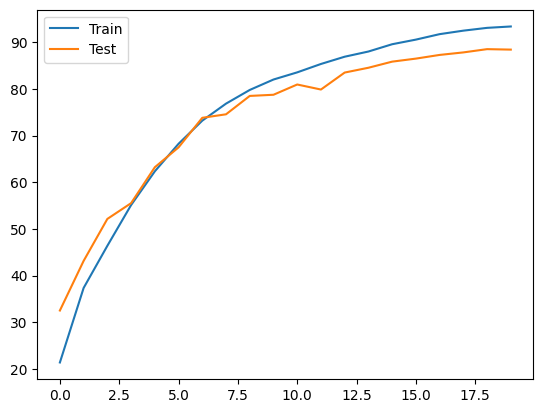

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
import matplotlib.pyplot as plt

# 1. Gerät erkennen
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Training auf: {device}")
if torch.cuda.is_available():
    print(f"GPU erkannt: {torch.cuda.get_device_name(0)}")

# 2. Data Augmentation
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# 3. Datensätze (Download=False, da lokal vorhanden)
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform_test)

# RTX 3500 Power nutzen: Batch Size auf 512 erhöht, num_workers auf 8 für deine 20 i7-Kerne
trainloader = torch.utils.data.DataLoader(trainset, batch_size=512, shuffle=True, num_workers=8, pin_memory=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=512, shuffle=False, num_workers=8, pin_memory=True)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# 4. Modell-Anpassung
model = resnet18(weights=None)
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.maxpool = nn.Identity()
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

# 5. Optimierung & AMP-Scaler
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20) # Besserer Scheduler
scaler = torch.amp.GradScaler('cuda') # NEU: Skaliert Gradienten für FP16 Training

# 6. Training Funktion mit AMP
def train_epoch(model, trainloader, criterion, optimizer, device, scaler):
    model.train()
    train_loss, correct, total = 0.0, 0, 0
    
    for inputs, targets in trainloader:
        inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
        optimizer.zero_grad()

        # NEU: Mixed Precision Kontext
        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, targets)

        # NEU: Skaliertes Backward-Passing
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        
    return train_loss / len(trainloader), 100. * correct / total

# 7. Test Funktion
def test_epoch(model, testloader, criterion, device):
    model.eval()
    test_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, targets in testloader:
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
            with torch.amp.autocast('cuda'): # Auch beim Testen für Speed nutzen
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return test_loss / len(testloader), 100. * correct / total

# 8. Main Loop
num_epochs = 20
train_losses, train_accs, test_losses, test_accs = [], [], [], []

print(f"\nStarte Training auf {torch.cuda.get_device_name(0)} mit AMP...\n")
for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, trainloader, criterion, optimizer, device, scaler)
    test_loss, test_acc = test_epoch(model, testloader, criterion, device)
    scheduler.step()
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    print(f'Epoch {epoch+1:02d}: Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}% | LR: {scheduler.get_last_lr()[0]:.4f}')

# Plotting & Speichern
torch.save(model.state_dict(), 'resnet18_cifar10_fast.pth')
plt.plot(train_accs, label='Train'); plt.plot(test_accs, label='Test'); plt.legend(); plt.show()


# Mit der Ada-Architektur deiner RTX 3500 ist Mixed Precision (AMP) extrem effizient. Dabei werden Berechnungen nicht in float32, sondern in float16 durchgeführt.
Vorteile:
Speed: Die Tensor-Kerne werden optimal genutzt (bis zu 3x schneller).
Speicher: Du verbrauchst weniger VRAM, was größere Batches erlaubt.
Hier ist dein angepasstes Skript mit AMP (markiert mit # NEU) und optimierten Einstellungen für dein HP ZBook:

## Version 2.1:

Training auf: cuda:0
GPU erkannt: NVIDIA RTX 3500 Ada Generation Laptop GPU

Starte Training auf NVIDIA RTX 3500 Ada Generation Laptop GPU...
------------------------------------------------------------
Epoch 01/30 | Zeit: 51.09s | Train Loss: 2.1213 | Train Acc: 26.12% | Test Loss: 1.6888 | Test Acc: 36.99%
Epoch 02/30 | Zeit: 50.98s | Train Loss: 1.4980 | Train Acc: 43.94% | Test Loss: 1.3774 | Test Acc: 48.81%
Epoch 03/30 | Zeit: 52.70s | Train Loss: 1.2393 | Train Acc: 54.65% | Test Loss: 1.1968 | Test Acc: 56.82%
Epoch 04/30 | Zeit: 54.85s | Train Loss: 1.0249 | Train Acc: 63.25% | Test Loss: 1.0294 | Test Acc: 64.12%
Epoch 05/30 | Zeit: 54.29s | Train Loss: 0.8653 | Train Acc: 69.21% | Test Loss: 0.8528 | Test Acc: 69.44%
Epoch 06/30 | Zeit: 54.31s | Train Loss: 0.7481 | Train Acc: 73.50% | Test Loss: 0.7941 | Test Acc: 72.51%
Epoch 07/30 | Zeit: 53.81s | Train Loss: 0.6413 | Train Acc: 77.52% | Test Loss: 0.7528 | Test Acc: 74.54%
Epoch 08/30 | Zeit: 54.60s | Train Loss: 0.5616 

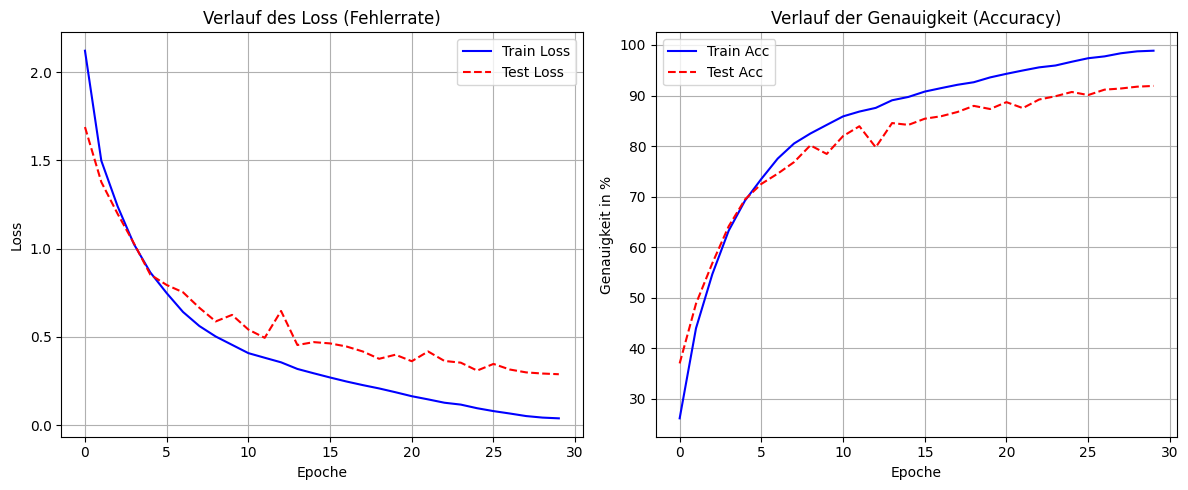

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
import matplotlib.pyplot as plt
import time  # NEU: Für Zeitmessung

# 1. Gerät erkennen (Deine RTX 3500 Ada)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Training auf: {device}")
if torch.cuda.is_available():
    print(f"GPU erkannt: {torch.cuda.get_device_name(0)}")

# 2. Data Augmentation
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# 3. Datensätze (Download=False, da bereits vorhanden)
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform_test)

# Optimiert für RTX 3500 Ada: 
# Batch Size 512 nutzt den VRAM besser aus, num_workers=8 nutzt deine i7-Kerne
trainloader = torch.utils.data.DataLoader(trainset, batch_size=512, shuffle=True, 
                                          num_workers=8, pin_memory=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=512, shuffle=False, 
                                         num_workers=8, pin_memory=True)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# 4. Modell-Definition (ResNet-18 optimiert für CIFAR-10)
model = resnet18(weights=None)
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.maxpool = nn.Identity()
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

# 5. Optimierung & AMP (Mixed Precision)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=35)
scaler = torch.amp.GradScaler('cuda') # Turbo-Modus für Tensor-Kerne

# 6. Training & Test Funktionen
def train_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, targets in loader:
        # non_blocking=True für schnelleren Datentransfer
        inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'): # FP16 Berechnung
            outputs = model(inputs)
            loss = criterion(outputs, targets)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    return running_loss / len(loader), 100. * correct / total

def test_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return running_loss / len(loader), 100. * correct / total

# 7. Main Loop mit Zeitmessung und Statistik
num_epochs = 30
history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

print(f"\nStarte Training auf {torch.cuda.get_device_name(0)}...")
print("-" * 60)

total_start_time = time.time()

for epoch in range(num_epochs):
    epoch_start_time = time.time() # Zeitmessung Start
    
    train_loss, train_acc = train_epoch(model, trainloader, criterion, optimizer, scaler, device)
    test_loss, test_acc = test_epoch(model, testloader, criterion, device)
    
    scheduler.step()
    epoch_duration = time.time() - epoch_start_time # Zeitmessung Ende
    
    # Speichere Werte für Grafik
    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)
    
    # Anzeige pro Epoche
    print(f"Epoch {epoch+1:02d}/{num_epochs} | "
          f"Zeit: {epoch_duration:.2f}s | "   
          f"Train Loss: {train_loss:.4f} | "
          f"Train Acc: {train_acc:.2f}% | "
          f"Test Loss: {test_loss:.4f} | "
          f"Test Acc: {test_acc:.2f}% | " 
          f"LR: {scheduler.get_last_lr()[0]:.4f}")

total_duration = time.time() - total_start_time
print("-" * 60)
print(f"Training abgeschlossen in {total_duration/60:.2f} Minuten.")

# 8. Grafik anzeigen
plt.figure(figsize=(12, 5))

# Plot für Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue')
plt.plot(history['test_loss'], label='Test Loss', color='red', linestyle='--')
plt.title('Verlauf des Loss (Fehlerrate)')
plt.xlabel('Epoche')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot für Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc', color='blue')
plt.plot(history['test_acc'], label='Test Acc', color='red', linestyle='--')
plt.title('Verlauf der Genauigkeit (Accuracy)')
plt.xlabel('Epoche')
plt.ylabel('Genauigkeit in %')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Modell speichern
torch.save(model.state_dict(), 'resnet18_cifar10_final.pth')


## Version 3.0
T_max=35 (bei Version 3.1: T_max=45, Berechnung für Training ist gleich wie 3.0)

hier sind smarte Verbesserungen gegen Overfitting + Robustheit:

Training auf: cuda:0
GPU erkannt: NVIDIA RTX 3500 Ada Generation Laptop GPU

Starte Training auf NVIDIA RTX 3500 Ada Generation Laptop GPU...
----------------------------------------------------------------------


Epoch 01/50 | Zeit: 51.12s | Train Loss: 2.4578 | Train Acc: 14.69% | Test Loss: 1.9989 | Test Acc: 26.85% | LR: 0.0998
  -> NEUES BESTES MODELL: 26.85%


Epoch 02/50 | Zeit: 51.99s | Train Loss: 2.0750 | Train Acc: 23.69% | Test Loss: 1.8556 | Test Acc: 36.62% | LR: 0.0992
  -> NEUES BESTES MODELL: 36.62%


Epoch 03/50 | Zeit: 51.69s | Train Loss: 1.9581 | Train Acc: 30.53% | Test Loss: 1.7500 | Test Acc: 41.16% | LR: 0.0982
  -> NEUES BESTES MODELL: 41.16%


Epoch 04/50 | Zeit: 52.91s | Train Loss: 1.8360 | Train Acc: 37.34% | Test Loss: 1.5722 | Test Acc: 50.24% | LR: 0.0968
  -> NEUES BESTES MODELL: 50.24%


...

Epoch 44/50 | Zeit: 52.20s | Train Loss: 0.8880 | Train Acc: 83.29% | Test Loss: 0.7600 | Test Acc: 88.76% | LR: 0.0154


Epoch 45/50 | Zeit: 52.39s | Train Loss: 0.8938 | Train Acc: 83.08% | Test Loss: 0.7616 | Test Acc: 88.75% | LR: 0.0188


Epoch 46/50 | Zeit: 52.34s | Train Loss: 0.8966 | Train Acc: 82.91% | Test Loss: 0.7939 | Test Acc: 87.20% | LR: 0.0225


Epoch 47/50 | Zeit: 52.82s | Train Loss: 0.8970 | Train Acc: 82.92% | Test Loss: 0.7887 | Test Acc: 87.87% | LR: 0.0263


Epoch 48/50 | Zeit: 52.39s | Train Loss: 0.9132 | Train Acc: 82.31% | Test Loss: 0.7658 | Test Acc: 88.45% | LR: 0.0303
Early Stopping nach Epoch 48 (keine Verbesserung seit 10 Epochen)
----------------------------------------------------------------------
Training abgeschlossen in 42.54 Minuten. Best Test Acc: 89.79%


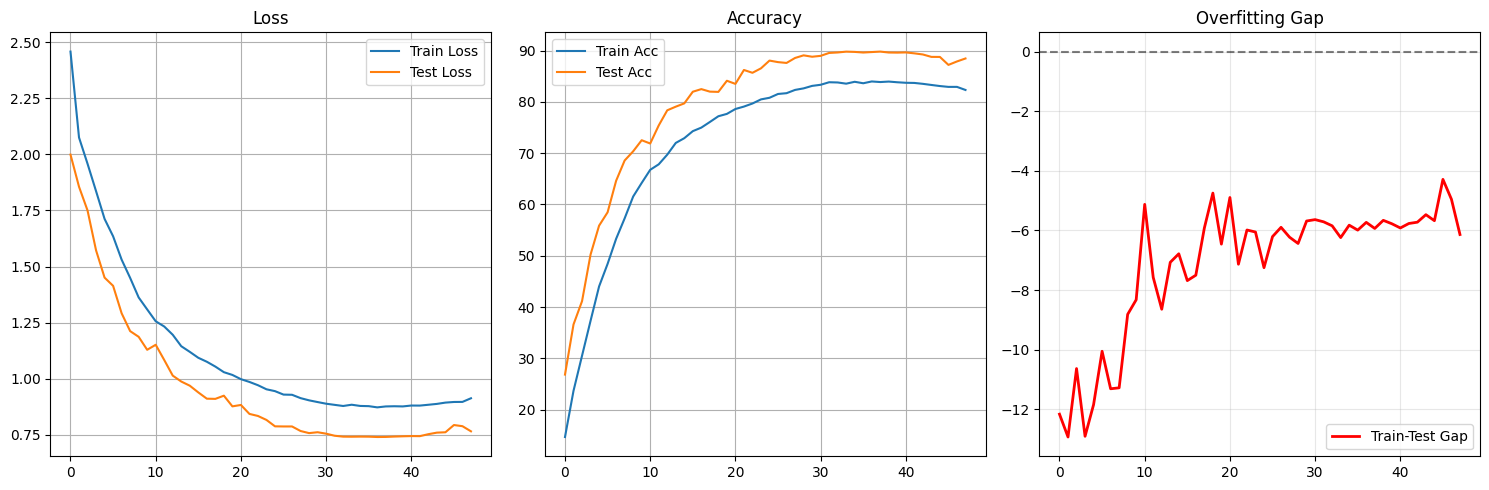

Bestes Modell gespeichert: resnet18_cifar10_best.pth


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
import matplotlib.pyplot as plt
import time
from tqdm import tqdm  # NEU: Progress-Bar
import os

# 1. Gerät erkennen
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Training auf: {device}")
if torch.cuda.is_available():
    print(f"GPU erkannt: {torch.cuda.get_device_name(0)}")

# 2. VERBESSERTE Data Augmentation (Anti-Overfitting!)
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandAugment(num_ops=2, magnitude=9),  # NEU: Starke Aug!
    transforms.AutoAugment(transforms.AutoAugmentPolicy.CIFAR10),  # NEU!
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# 3. Datensätze
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=512, shuffle=True, 
                                          num_workers=8, pin_memory=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=512, shuffle=False, 
                                         num_workers=8, pin_memory=True)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# 4. VERBESSERTES Modell (Dropout gegen Overfitting!)
model = resnet18(weights=None)
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.maxpool = nn.Identity()
model.fc = nn.Sequential(  # NEU: Dropout + Linear
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, 10)
)
model = model.to(device)

# 5. Optimierung
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # NEU: Label Smoothing
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)  # Mehr WD
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=35)
scaler = torch.amp.GradScaler('cuda')

# 6. Training & Test (unverändert, aber mit tqdm)
def train_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    progress_bar = tqdm(loader, desc="Train", leave=False)
    for inputs, targets in progress_bar:
        inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})
    return running_loss / len(loader), 100. * correct / total

def test_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        progress_bar = tqdm(loader, desc="Test ", leave=False)
        for inputs, targets in progress_bar:
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return running_loss / len(loader), 100. * correct / total

# 7. Main Loop + EARLY STOPPING
num_epochs = 50  # Mehr Epochen möglich
patience = 10    # NEU: Early Stopping
best_test_acc = 0
patience_counter = 0
history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

print(f"\nStarte Training auf {torch.cuda.get_device_name(0)}...")
print("-" * 70)

total_start_time = time.time()
for epoch in range(num_epochs):
    epoch_start_time = time.time()
    
    train_loss, train_acc = train_epoch(model, trainloader, criterion, optimizer, scaler, device)
    test_loss, test_acc = test_epoch(model, testloader, criterion, device)
    
    scheduler.step()
    epoch_duration = time.time() - epoch_start_time
    
    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)
    
    print(f"Epoch {epoch+1:02d}/{num_epochs} | "
          f"Zeit: {epoch_duration:.2f}s | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}% | "
          f"LR: {scheduler.get_last_lr()[0]:.4f}")
    
    # NEU: Early Stopping & Best Model Save
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), 'resnet18_cifar10_best.pth')
        patience_counter = 0
        print(f"  -> NEUES BESTES MODELL: {best_test_acc:.2f}%")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early Stopping nach Epoch {epoch+1} (keine Verbesserung seit {patience} Epochen)")
            break

total_duration = time.time() - total_start_time
print("-" * 70)
print(f"Training abgeschlossen in {total_duration/60:.2f} Minuten. Best Test Acc: {best_test_acc:.2f}%")

# 8. Grafik
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['test_loss'], label='Test Loss')
plt.title('Loss')
plt.legend(); plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['test_acc'], label='Test Acc')
plt.title('Accuracy')
plt.legend(); plt.grid(True)



plt.subplot(1, 3, 3)
gap = np.array(history['train_acc']) - np.array(history['test_acc'])
plt.plot(gap, label='Train-Test Gap', color='red', linewidth=2)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.title('Overfitting Gap')
plt.legend(); plt.grid(True, alpha=0.3)





plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("Bestes Modell gespeichert: resnet18_cifar10_best.pth")


## Version 3.1
T_max=45

Formeln:

Precision= TP/  (TP+FP)

Recall=TP/ (TP+FN)

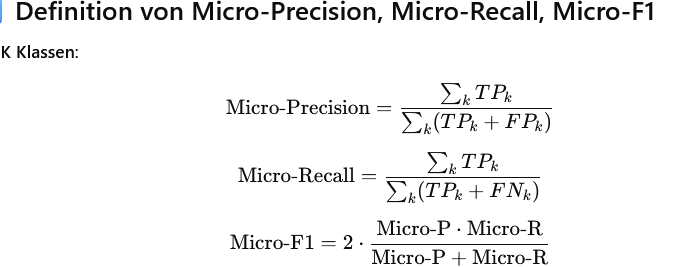

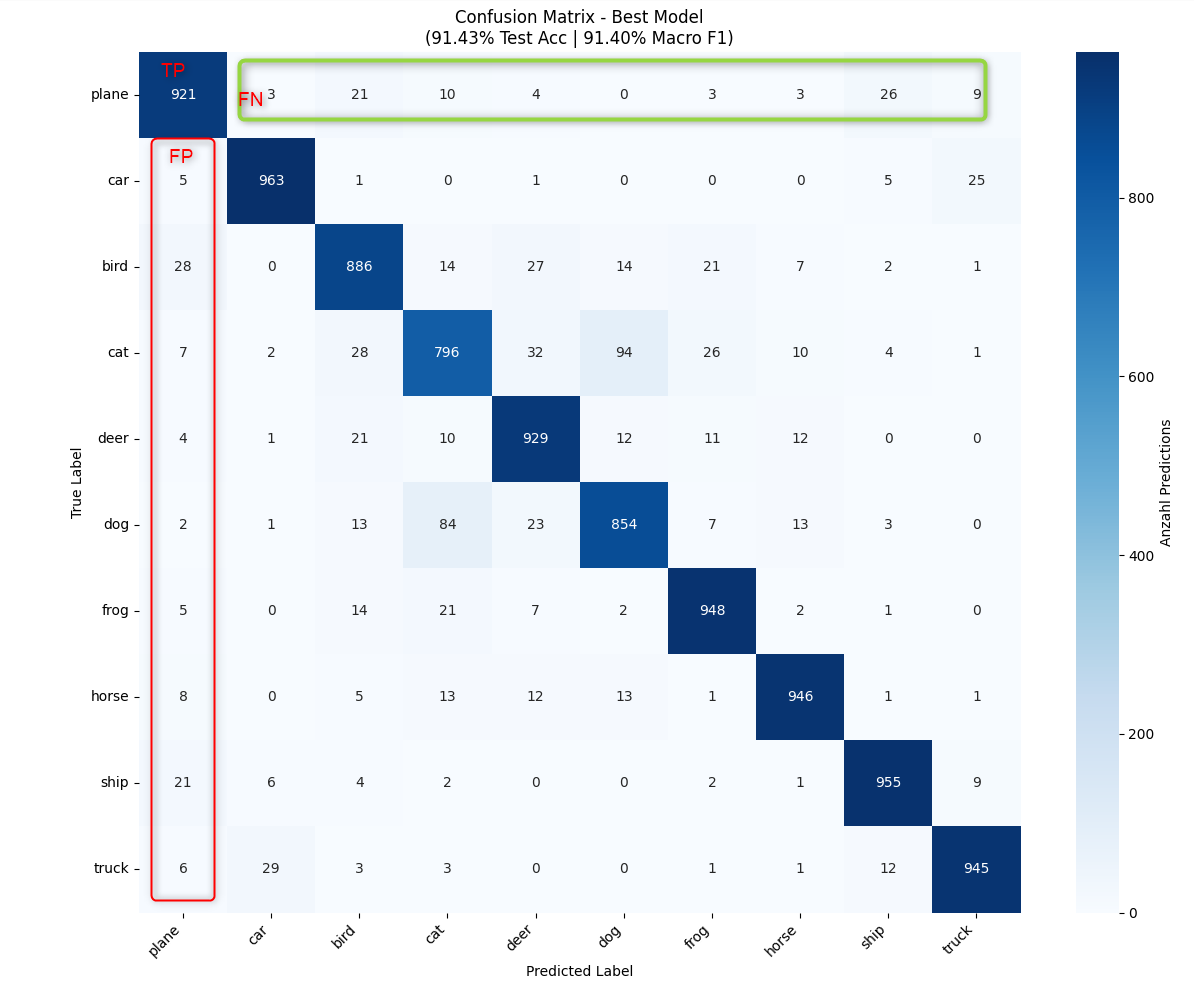



🚀 Training auf: cuda:0
💎 GPU: NVIDIA RTX 3500 Ada Generation Laptop GPU | VRAM: 12.9GB
⚙️  num_workers: 8

Starte Training auf NVIDIA RTX 3500 Ada Generation Laptop GPU...
----------------------------------------------------------------------


Epoch 01/50 | Zeit: 53.48s | Train Loss: 2.5314 | Train Acc: 12.61% | Test Loss: 2.1035 | Test Acc: 21.46% | LR: 0.0999
  🎉 NEUES BESTES MODELL: 21.46%


Epoch 02/50 | Zeit: 53.36s | Train Loss: 2.0968 | Train Acc: 22.59% | Test Loss: 1.8798 | Test Acc: 32.48% | LR: 0.0995
  🎉 NEUES BESTES MODELL: 32.48%


Epoch 03/50 | Zeit: 53.29s | Train Loss: 1.9606 | Train Acc: 30.26% | Test Loss: 1.6929 | Test Acc: 43.94% | LR: 0.0989
  🎉 NEUES BESTES MODELL: 43.94%


Epoch 04/50 | Zeit: 52.52s | Train Loss: 1.8370 | Train Acc: 37.28% | Test Loss: 1.6175 | Test Acc: 48.58% | LR: 0.0981
  🎉 NEUES BESTES MODELL: 48.58%


...

Epoch 46/50 | Zeit: 51.78s | Train Loss: 0.8124 | Train Acc: 86.74% | Test Loss: 0.7035 | Test Acc: 91.32% | LR: 0.0001


Epoch 47/50 | Zeit: 612.78s | Train Loss: 0.8181 | Train Acc: 86.40% | Test Loss: 0.7033 | Test Acc: 91.39% | LR: 0.0005
  🎉 NEUES BESTES MODELL: 91.39%


Epoch 48/50 | Zeit: 51.17s | Train Loss: 0.8119 | Train Acc: 86.73% | Test Loss: 0.7039 | Test Acc: 91.43% | LR: 0.0011
  🎉 NEUES BESTES MODELL: 91.43%


Epoch 49/50 | Zeit: 51.12s | Train Loss: 0.8134 | Train Acc: 86.74% | Test Loss: 0.7043 | Test Acc: 91.33% | LR: 0.0019


Epoch 50/50 | Zeit: 51.95s | Train Loss: 0.8141 | Train Acc: 86.70% | Test Loss: 0.7063 | Test Acc: 91.21% | LR: 0.0030
----------------------------------------------------------------------
Training abgeschlossen in 52.90 Minuten. Best Test Acc: 91.43%


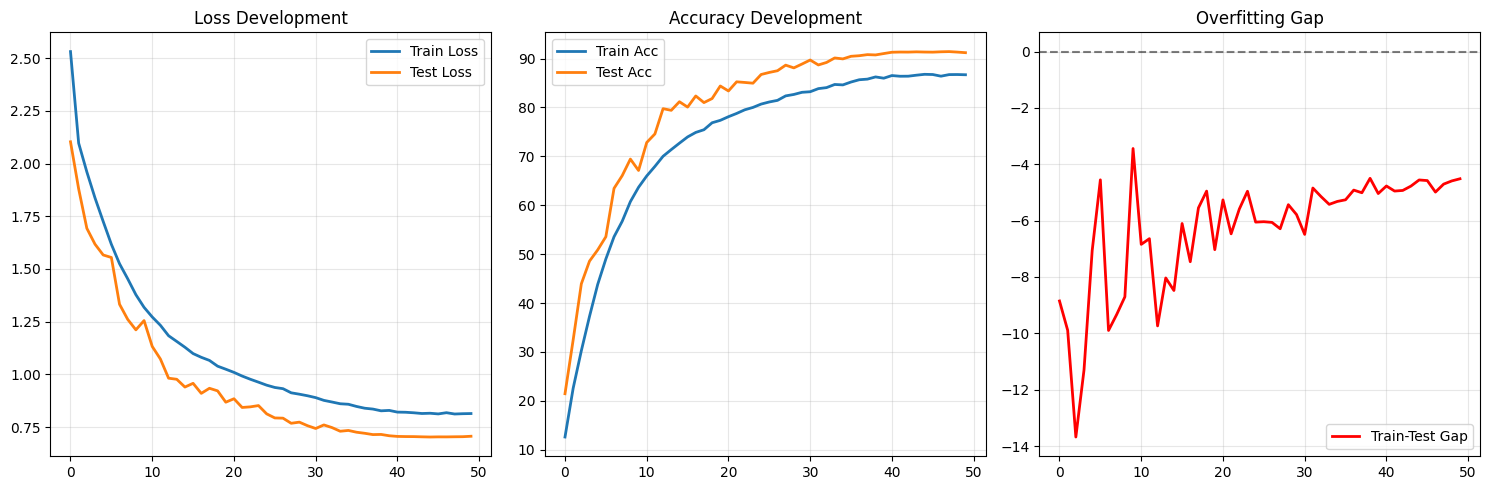


🔥 Lade BESTES Modell und berechne Confusion Matrix...


Confusion Matrix: 100%|██████████| 20/20 [00:20<00:00,  1.04s/it]


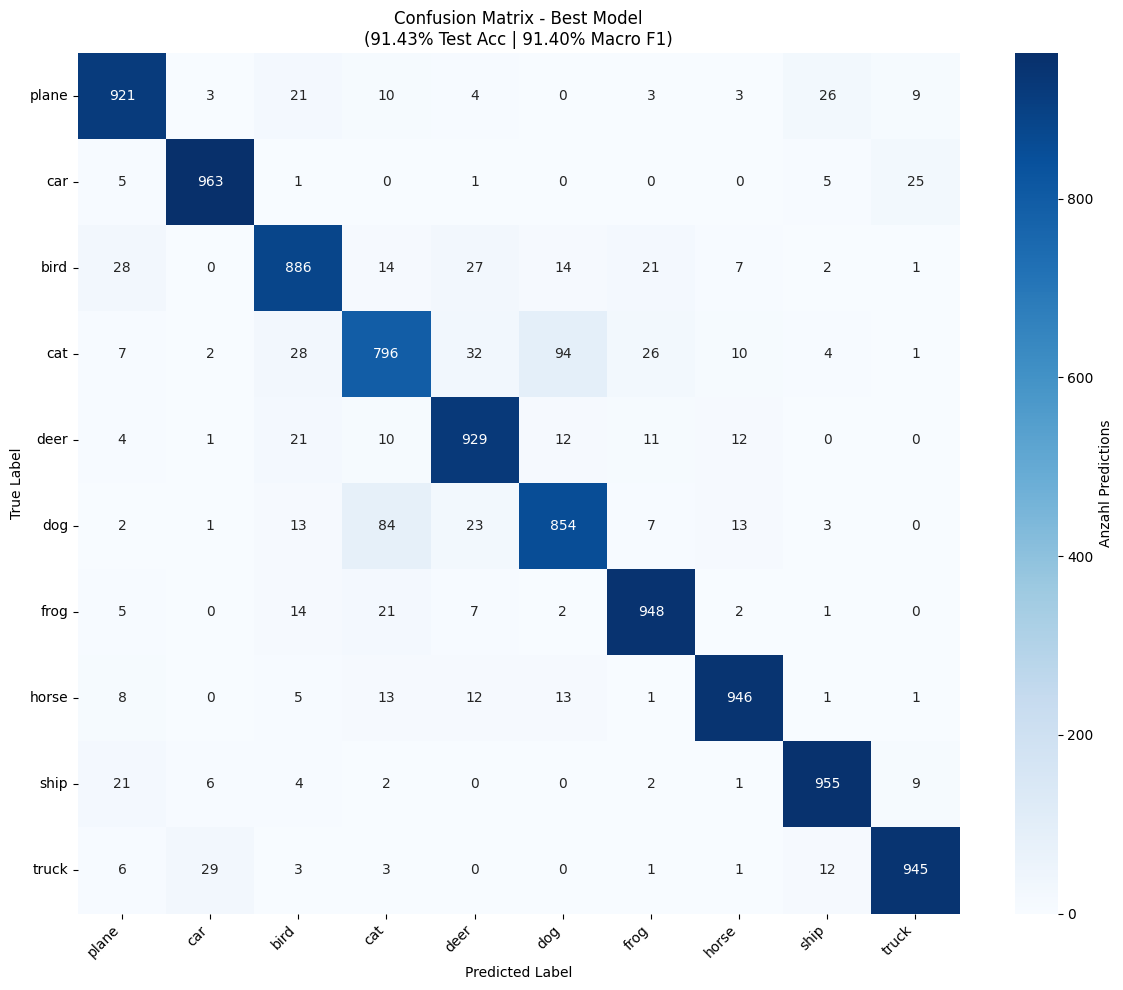


📊 PER-CLASS ACCURACY:
plane     :  92.10%
car       :  96.30%
bird      :  88.60%
cat       :  79.60%
deer      :  92.90%
dog       :  85.40%
frog      :  94.80%
horse     :  94.60%
ship      :  95.50%
truck     :  94.50%

🏆 BEST CLASS: car       :  96.30%
📉 WORST CLASS: cat       :  79.60%
🎯 MACRO F1-SCORE: 91.40%

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       plane       0.91      0.92      0.92      1000
         car       0.96      0.96      0.96      1000
        bird       0.89      0.89      0.89      1000
         cat       0.84      0.80      0.82      1000
        deer       0.90      0.93      0.91      1000
         dog       0.86      0.85      0.86      1000
        frog       0.93      0.95      0.94      1000
       horse       0.95      0.95      0.95      1000
        ship       0.95      0.95      0.95      1000
       truck       0.95      0.94      0.95      1000

    accuracy                           0.91     10000
   mac

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
import matplotlib.pyplot as plt
import time
from tqdm import tqdm
import os
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Gerät erkennen (FIX: mehr Info)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"🚀 Training auf: {device}")
if torch.cuda.is_available():
    print(f"💎 GPU: {torch.cuda.get_device_name(0)} | VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f}GB")

# 2. Data Augmentation (perfekt! ✅)
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.CIFAR10),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# 3. Datensätze & Loader (🔥 FIX: download=True + dynamische Workers)
num_workers = min(8, os.cpu_count() or 4)  # Dynamisch!
print(f"⚙️  num_workers: {num_workers}")

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=512, shuffle=True, 
                                          num_workers=num_workers, pin_memory=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=512, shuffle=False, 
                                         num_workers=num_workers, pin_memory=True)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# 4. Modell (perfekt angepasst für CIFAR10! ✅)
model = resnet18(weights=None)
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.maxpool = nn.Identity()
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, 10)
)
model = model.to(device)

# 5. Optimierung (🔥 FIX: T_max=50 statt 35!)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=45)  # FIX! T_max=35, 45
scaler = torch.amp.GradScaler('cuda')

# 6. Training & Test Funktionen (unverändert - top! ✅)
def train_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    progress_bar = tqdm(loader, desc="Train", leave=False)
    for inputs, targets in progress_bar:
        inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})
    return running_loss / len(loader), 100. * correct / total

def test_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        progress_bar = tqdm(loader, desc="Test ", leave=False)
        for inputs, targets in progress_bar:
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return running_loss / len(loader), 100. * correct / total

# 7. Confusion Matrix (🔥 FIX: f1_score hinzugefügt)
def compute_confusion_matrix(model, testloader, device, classes):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(testloader, desc="Confusion Matrix"):
            inputs = inputs.to(device, non_blocking=True)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    cm = confusion_matrix(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro') * 100
    return cm, all_labels, all_preds, macro_f1

# 8. Main Training Loop (robustere Early Stopping)
num_epochs = 50
patience = 10
best_test_acc = 0
patience_counter = 0
history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

print(f"\nStarte Training auf {torch.cuda.get_device_name(0)}...")
print("-" * 70)

total_start_time = time.time()
for epoch in range(num_epochs):
    epoch_start_time = time.time()
    
    train_loss, train_acc = train_epoch(model, trainloader, criterion, optimizer, scaler, device)
    test_loss, test_acc = test_epoch(model, testloader, criterion, device)
    
    scheduler.step()
    epoch_duration = time.time() - epoch_start_time
    
    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)
    
    print(f"Epoch {epoch+1:02d}/{num_epochs} | "
          f"Zeit: {epoch_duration:.2f}s | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}% | "
          f"LR: {scheduler.get_last_lr()[0]:.4f}")
    
    # Early Stopping + Best Model Save
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), 'resnet18_cifar10_best.pth')
        patience_counter = 0
        print(f"  🎉 NEUES BESTES MODELL: {best_test_acc:.2f}%")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"🛑 Early Stopping nach Epoch {epoch+1}")
            break

total_duration = time.time() - total_start_time
print("-" * 70)
print(f"Training abgeschlossen in {total_duration/60:.2f} Minuten. Best Test Acc: {best_test_acc:.2f}%")

# 9. Training-Plots (perfekt! ✅)
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train Loss', linewidth=2)
plt.plot(history['test_loss'], label='Test Loss', linewidth=2)
plt.title('Loss Development')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(history['train_acc'], label='Train Acc', linewidth=2)
plt.plot(history['test_acc'], label='Test Acc', linewidth=2)
plt.title('Accuracy Development')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
gap = np.array(history['train_acc']) - np.array(history['test_acc'])
plt.plot(gap, label='Train-Test Gap', color='red', linewidth=2)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.title('Overfitting Gap')
plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# 10. BESTES MODELL LADEN + FULL EVALUATION 🔥
print("\n🔥 Lade BESTES Modell und berechne Confusion Matrix...")
checkpoint = torch.load('resnet18_cifar10_best.pth', map_location=device)
model.load_state_dict(checkpoint)
model.eval()

cm, true_labels, predictions, macro_f1 = compute_confusion_matrix(model, testloader, device, classes)

# 11. Confusion Matrix Plot (schöner! ✨)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Anzahl Predictions'},
            xticklabels=classes, yticklabels=classes)
plt.title(f'Confusion Matrix - Best Model\n({best_test_acc:.2f}% Test Acc | {macro_f1:.2f}% Macro F1)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# 12. DETAILED ANALYSIS 📊
class_acc = cm.diagonal() / cm.sum(axis=1) * 100
print("\n📊 PER-CLASS ACCURACY:")
for i, cls in enumerate(classes):
    print(f"{cls:10}: {class_acc[i]:6.2f}%")

best_class = np.argmax(class_acc)
worst_class = np.argmin(class_acc)
print(f"\n🏆 BEST CLASS: {classes[best_class]:10}: {class_acc[best_class]:6.2f}%")
print(f"📉 WORST CLASS: {classes[worst_class]:10}: {class_acc[worst_class]:6.2f}%")
print(f"🎯 MACRO F1-SCORE: {macro_f1:.2f}%")

print("\n📋 CLASSIFICATION REPORT:")
print(classification_report(true_labels, predictions, target_names=classes))

print("\n💾 FILES:")
print("✅ resnet18_cifar10_best.pth (Best Model)")
print("✅ training_curves.png")
print("✅ confusion_matrix.png")
print("🎉 Fertig! Dein ResNet18 rockt CIFAR10! 🚀")